# 18 - Job Family Clustering from Graph Embeddings

This notebook implements the job family clustering step for Chapter 2 of the Job Intelligence Engine. Starting from Node2Vec embeddings learned on the job–skill bipartite graph, the objective is to move from continuous representations of jobs to an interpretable, reusable structural artefact: a set of latent job families that capture how roles are organised across the job market.

The clustering is performed on job embeddings only. Jobs are treated as the primary units of the system because they act as the anchor for downstream analysis, aggregation, and recommendation. Each job embedding is indexed by `job_id`, allowing the resulting job families to be joined back to titles, locations, industries, salary information, and skill requirements without contaminating the clustering process itself.

Before clustering, embeddings are L2-normalised so that Euclidean distance reflects directional similarity in the embedding space rather than vector magnitude. Job families are then inferred using KMeans clustering, with the number of clusters selected using the silhouette score as a simple stability heuristic. A value of *k = 20* is chosen as it lies within a broad plateau near the silhouette maximum, balancing structural resolution with interpretability.

The output of this notebook is a single, stable artefact mapping each `job_id` to a `job_family_id`. This artefact is intentionally minimal and serves as a foundational input for later modules, including skill ecosystem analysis, industry and domain specialisation summaries, and downstream job and skill recommendation components. The goal at this stage is structural discovery rather than taxonomic perfection, and no further optimisation or refinement of cluster assignments is performed here.


## Set Up

### Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
#===
import sys
from pathlib import Path

### Path

In [2]:
project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))
project_root

PosixPath('/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine')

In [3]:
from src.job_intel.features.embedding_loader import load_node2vec_embeddings

### Load embeddings

In [4]:
job_emb, skill_emb = load_node2vec_embeddings(tag='v01')

In [5]:
job_emb.head()

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63
job_id,,,,,,,,,,,,,,,,,,,,,
0,-0.050411,0.047540,0.352817,0.247387,-0.018104,-0.028317,-0.001943,-0.354199,-0.230722,0.007877,...,0.122435,-0.192289,0.309224,-0.195267,0.141538,-0.109489,-0.209628,-0.175297,0.214267,0.008826
1,-0.289258,-0.113007,0.024459,0.418149,-0.045365,-0.210297,-0.012425,0.382970,-0.112916,-0.125571,...,0.119459,0.139749,0.228617,-0.261526,0.005694,0.001792,-0.160209,0.176933,-0.055536,0.014159
2,-0.155415,-0.216808,0.257496,0.288886,-0.043927,-0.080180,0.104272,0.063548,-0.139189,-0.184298,...,0.562738,0.109193,0.202710,-0.275555,-0.091857,0.044713,-0.162306,0.202350,-0.255020,0.111398
3,-0.027495,-0.085064,0.248121,0.238406,-0.018129,-0.061358,0.158865,-0.197091,-0.325542,0.083742,...,0.246064,-0.069967,0.040930,-0.180615,0.156418,0.051398,-0.153494,0.117994,-0.111381,-0.165436
4,0.023282,0.015768,-0.064248,-0.037239,0.079508,-0.233489,0.606910,0.278999,0.164355,0.113560,...,0.282145,-0.187484,0.306351,-0.137420,-0.250154,0.035214,0.026194,0.349513,-0.063748,-0.051188


In [6]:
job_emb.isna().sum().sum()

0

In [7]:
skill_emb.head()

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63
skill,,,,,,,,,,,,,,,,,,,,,
core_programming__basic_prob,-0.112756,-0.189017,0.240199,0.017991,0.168215,-0.451236,-0.136170,0.123233,0.078271,-0.269565,...,0.399301,-0.027866,-0.100379,-0.251692,0.025572,-0.177167,-0.175215,0.204694,0.092970,0.065324
core_programming__intermediate_prob,-0.085401,0.272583,0.540022,0.344871,0.020368,0.138199,-0.323431,0.396596,0.076551,-0.251645,...,0.589068,0.044497,-0.031481,0.006070,0.210170,0.031482,-0.152592,0.406975,0.144718,-0.140824
core_programming__advanced_prob,0.622580,0.061518,1.015188,0.441058,-0.071451,0.356048,-0.210664,-0.261080,-0.517891,-0.001236,...,0.590781,-0.116449,0.190862,-0.537874,0.002408,-0.392553,-0.123868,0.352035,-0.991993,0.388522
data_engineering_pipelines__basic_prob,0.503347,-0.025654,0.611696,-0.287454,-0.586673,-0.239030,0.361503,0.600193,0.392811,-0.526925,...,0.490094,0.379866,-0.289869,0.334395,-0.226643,-0.153653,0.124811,0.018329,-0.167979,-0.500521
data_engineering_pipelines__intermediate_prob,-0.115282,-0.090698,0.406704,0.030909,0.212335,-0.444862,0.118079,-0.327422,-0.124292,-0.064657,...,0.164946,-0.249836,-0.071534,-0.143214,-0.306987,0.189237,0.049286,-0.352176,-0.132795,-0.088354


In [8]:
skill_emb.isna().sum().sum()

0

## Preparing data - checks and normalisation

In [9]:
print(f'NAs in the skill embeddings = {skill_emb.isna().sum().sum()}.')
print(f'NAs in the job embeddings = {job_emb.isna().sum().sum()}.')

NAs in the skill embeddings = 0.
NAs in the job embeddings = 0.


In [10]:
from sklearn.preprocessing import normalize

In [11]:
job_emb_norm = normalize(job_emb, norm='l2')
skill_emb_norm = normalize(skill_emb, norm='l2')

In [13]:
print(f'NAs in the skill embeddings = {np.isnan(skill_emb_norm).sum()}.')
print(f'NAs in the job embeddings = {np.isnan(job_emb_norm).sum()}.')
print(f'Shape maintained for skill embeddigs? {skill_emb.shape == skill_emb_norm.shape}.')
print(f'Shape maintained for skill embeddigs? {job_emb.shape == job_emb_norm.shape}.')
print(f'Unit norm check: {np.sqrt((job_emb_norm[:10]**2).sum(axis=1))}')

NAs in the skill embeddings = 0.
NAs in the job embeddings = 0.
Shape maintained for skill embeddigs? True.
Shape maintained for skill embeddigs? True.
Unit norm check: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Clustering (KMeans)

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

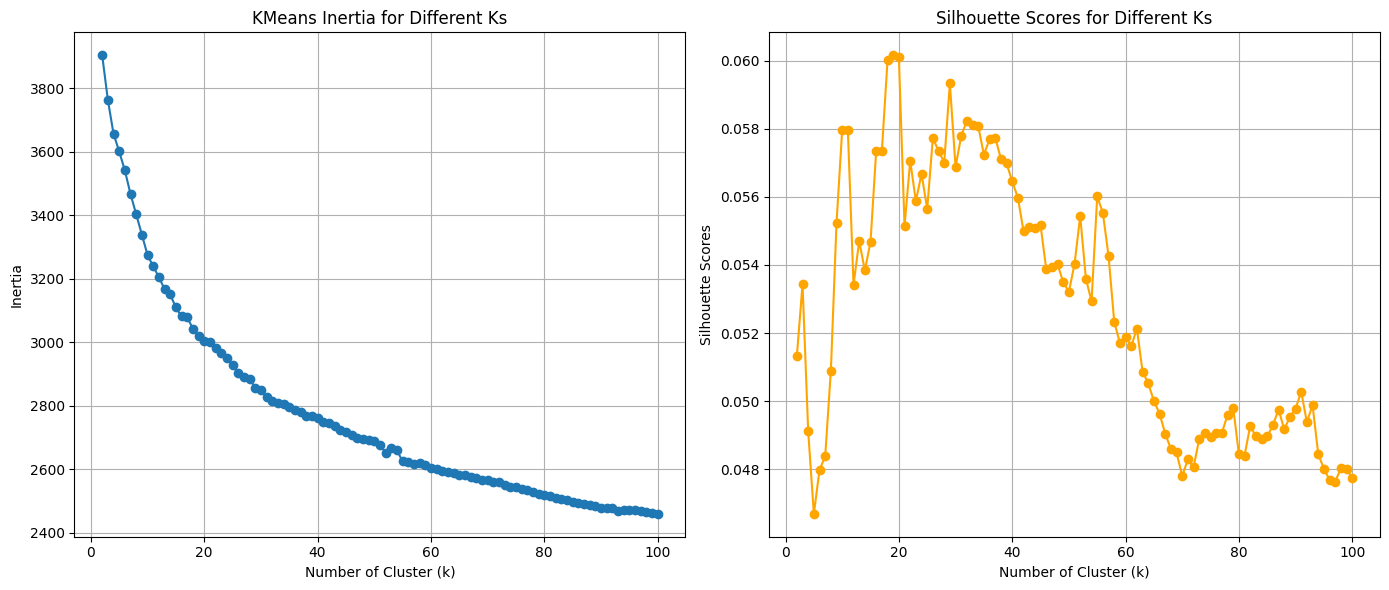

In [16]:
max_K = 100

inertia = []

sil_scores_ls = []

Kvalues = range(2, max_K +1 )

FeaturesTest = job_emb_norm

for k in Kvalues:
    ktest = KMeans(
                n_clusters= k,
                random_state= 42,
                max_iter= 1000
                   )
    cluster_labels = ktest.fit_predict(FeaturesTest)

    sil_scores = silhouette_score(FeaturesTest, cluster_labels)

    sil_scores_ls.append(sil_scores)

    inertia.append(ktest.inertia_)




plt.figure (figsize= (14,6))

plt.subplot(1,2,1)
plt.plot(Kvalues, 
         inertia, 
         marker = 'o',)
plt.title('KMeans Inertia for Different Ks')
plt.xlabel('Number of Cluster (k)')
plt.ylabel('Inertia')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(Kvalues, 
         sil_scores_ls, 
         marker = 'o',
         color = 'orange')

plt.title('Silhouette Scores for Different Ks')
plt.xlabel('Number of Cluster (k)')
plt.ylabel('Silhouette Scores')
plt.grid(True)

plt.tight_layout()

To determine an appropriate number of job families, KMeans clustering was evaluated across a range of cluster counts using the silhouette score, which measures how well jobs are separated relative to within-cluster cohesion. The silhouette curve shows a clear increase in clustering quality from low values of k, reaching a broad maximum around k ≈ 18–20, followed by a gradual decline as k increases further. Importantly, the curve exhibits a wide plateau rather than a sharp peak, indicating that job structure in the embedding space is continuous rather than partitioned into a small number of discrete, well-separated groups. In such cases, the objective is not to maximise the silhouette score but to identify a stable region that balances structural resolution and interpretability. Based on this criterion, k = 20 was selected as the final number of job families: it lies near the silhouette maximum, captures meaningful heterogeneity in job roles, and remains sufficiently compact to support downstream aggregation, interpretation, and reuse across later project modules.

In [30]:
km_model_jobs = KMeans(n_clusters=20,
                       random_state=42,
                       n_init='auto')

In [31]:
labels_km_jobs = km_model_jobs.fit_predict(job_emb_norm)
km_jobs_df = (pd.DataFrame({'job_id' : job_emb.index, 
                            'job_family_id' : labels_km_jobs}))

## Save data

In [32]:
from src.job_intel.config import PROCESSED_DATA_DIR
km_jobs_df.to_csv(PROCESSED_DATA_DIR / "job_families_graph_embeddings.csv")


# == End of Script ==